# 02 - Data pre-processing: Inter Analysis

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   POLITECNICO DI TORINO — MSc Mathematical Engineering           ║
# ║   THESIS: Advanced Study of Epigenetic Mechanisms in Neoplasms   ║
# ╟──────────────────────────────────────────────────────────────────╢
# ║ Author:       Elisabetta Roviera (s328422)                       ║
# ║ Supervisors:  Dr. Sandro Gambino, Prof. Alfredo Benso            ║
# ╟──────────────────────────────────────────────────────────────────╢
# ║ Notebook:     02-inter-analysis-data-pre-processing              ║
# ║ Description:  Inter analysis for data pre-processing             ║
# ║ Dataset(s):   GSE69914, GSE225845, G287331                       ║
# ║ Repository:   github.com/elisabettaroviera/THESIS                ║
# ╟──────────────────────────────────────────────────────────────────╢
# ║ Date: 02-Jen-2026 | Python 3.11.13                               ║
# ╚══════════════════════════════════════════════════════════════════╝


### Libraries

In [2]:
# Latex
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [5]:
# Import
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch
from pathlib import Path
from matplotlib_venn import venn3

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [4]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

## INTERSECTION OF CpGs

In [9]:
# DATASETS

OUTDIR = "./02_inter_dataset_analysis"
os.makedirs(OUTDIR, exist_ok=True)

ID_COL    = "id_tissue"
LABEL_COL = "label"

LABELS_USE = [0, 1]   # Normal + Adjacent
# LABELS_USE = [0, 1, 2]  # se vuoi includere Tumor

datasets = {
    "GSE69914": {
        "beta":  "/kaggle/input/gse69914-parquet/GSE69914.parquet",
        "pheno": "/kaggle/input/pheno-gse69914/pheno_GSE69914.parquet",
        "platform": "450K"
    },
    "GSE225845": {
        "beta":  "/kaggle/input/gse225845-parquet/GSE225845.parquet",
        "pheno": "/kaggle/input/pheno-gse225845/pheno_GSE225845.parquet",
        "platform": "EPIC"
    },
    "GSE287331": {
        "beta":  "/kaggle/input/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
        "pheno": "/kaggle/input/1-pheno-gse287331-parquet/pheno_GSE287331.parquet",
        "platform": "EPIC"
    }
}


In [15]:
# VENN DIAGRAM

def plot_venn3_with_clean_legend(
    A, B, C,
    labels_short=("GSE69914", "GSE225845", "GSE287331"),
    title="CpG overlap across datasets",
    alpha=0.35,
    figsize=(6.8, 4.5),
    legend_space=0.32,
    out_pdf=None,              
    dpi=300
):
    """
    3-way Venn diagram with:
    - legend colors EXACTLY matching Venn intersections
    - short dataset names
    - legend outside the plot area
    - viridis colormap
    - explicit apply_thesis_style call
    - optional PDF saving
    """

    apply_thesis_style(
    use_tex=True,
    legend_outside=False
)

    cmap = mpl.cm.get_cmap("viridis")

    fig, ax = plt.subplots(figsize=figsize)

    # reserve space for legend (prevents overlap)
    ax.set_position([0.05, 0.10, 1.0 - legend_space - 0.08, 0.82])

    v = venn3(
        subsets=(A, B, C),
        set_labels=labels_short,
        set_colors=(cmap(0.15), cmap(0.55), cmap(0.85)),
        alpha=alpha,
        ax=ax
    )

    # font sizes
    for t in (v.set_labels or []):
        if t:
            t.set_fontsize(11)
    for t in (v.subset_labels or []):
        if t:
            t.set_fontsize(10)

    # ---- exact colors from the venn patches ----
    patch_all3 = v.get_patch_by_id("111")   # A ∩ B ∩ C
    patch_epic = v.get_patch_by_id("011")   # B ∩ C

    handles = [
        Patch(
            facecolor=patch_all3.get_facecolor(),
            edgecolor="none",
            label=f"{labels_short[0]} $\\cap$ {labels_short[1]} $\\cap$ {labels_short[2]} = {len(A & B & C)}"
        ),
        Patch(
            facecolor=patch_epic.get_facecolor(),
            edgecolor="none",
            label=f"{labels_short[1]} $\\cap$ {labels_short[2]} = {len(B & C)}"
        ),
    ]

    ax.legend(
        handles=handles,
        title="Number of intersections",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        fontsize=10,
        title_fontsize=11,
        handlelength=1.8
    )
    
    if out_pdf is not None:
        fig.savefig(out_pdf, format="pdf", bbox_inches="tight")

    plt.show()

    return {
        "A_cap_B_cap_C": len(A & B & C),
        "B_cap_C": len(B & C)
    }


In [6]:
def get_cpg_ids_from_beta_parquet(
    beta_parquet_path,
    id_col="id_tissue",
    label_col="label"
):
    """
    Extract CpG IDs from a beta-value parquet file.

    CpGs are defined as all columns except sample ID and label.

    Returns
    -------
    set
        Set of CpG identifiers.
    """
    beta = pl.scan_parquet(beta_parquet_path)

    exclude = {id_col, label_col}

    cpg_ids = [
        col for col in beta.columns
        if col not in exclude
    ]

    return set(cpg_ids)


In [10]:
cpg_69914_pre = get_cpg_ids_from_beta_parquet(
    datasets["GSE69914"]["beta"],
    id_col=ID_COL,
    label_col=LABEL_COL
)

cpg_225845_pre = get_cpg_ids_from_beta_parquet(
    datasets["GSE225845"]["beta"],
    id_col=ID_COL,
    label_col=LABEL_COL
)

cpg_287331_pre = get_cpg_ids_from_beta_parquet(
    datasets["GSE287331"]["beta"],
    id_col=ID_COL,
    label_col=LABEL_COL
)


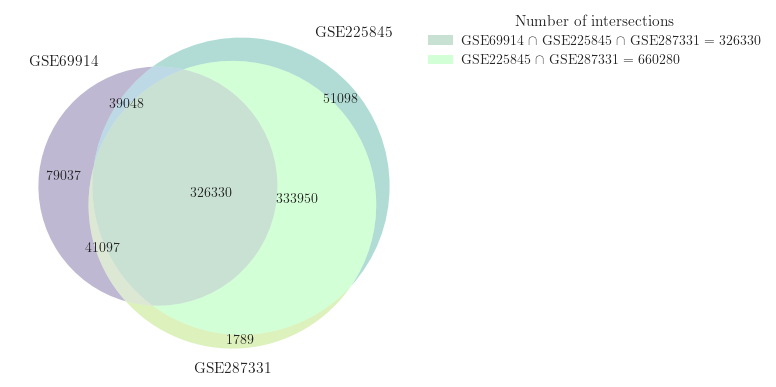

{'A_cap_B_cap_C': 326330, 'B_cap_C': 660280}

In [16]:
# PRE PRE-PROCESSING CpG SETS
plot_venn3_with_clean_legend(
    cpg_69914_pre,
    cpg_225845_pre,
    cpg_287331_pre,
    out_pdf="venn_cpg_overlap_pre_preprocessing.pdf"
)


In [17]:
# PATHS BLACKLIST CpG (per dataset)
CPG_DROP_MAP = {
    "GSE69914":  "/kaggle/input/removed-cpgs-all-filters-summary-gse69914/removed_cpgs_all_filters_summary_gse69914.csv",
    "GSE225845": "/kaggle/input/removed-cpgs-all-filters-summary-gse225845/removed_cpgs_all_filters_summary_gse225845.csv",
    "GSE287331": "/kaggle/input/removed-cpgs-all-filters-summary-gse287331/removed_cpgs_all_filters_summary_gse287331.csv",
}

# container per le CpG post-preprocessing
cpg_post = {}

# APPLY FILTERING
for name, cfg in datasets.items():
    print(f"\n=== Processing {name} ===")

    # ---- load CpG drop list ----
    drop_path = CPG_DROP_MAP[name]
    drop_df = pl.read_csv(drop_path)

    if "CpG_ID" not in drop_df.columns:
        raise ValueError(f"[{name}] 'CpG_ID' column not found in {drop_path}")

    cpg_to_remove = set(
        drop_df["CpG_ID"]
        .cast(pl.Utf8)
        .str.strip_chars()
        .to_list()
    )

    print(f"CpGs in drop list: {len(cpg_to_remove):,}")

    # ---- load dataset ----
    beta = pl.read_parquet(cfg["beta"])

    # CpGs present in dataset
    cpg_cols = {
        c for c in beta.columns
        if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
    }

    # effective removal
    cpg_removed = cpg_cols & cpg_to_remove
    print(f"CpGs removed (present in dataset): {len(cpg_removed):,}")

    # keep columns
    cpg_final = cpg_cols - cpg_removed
    cpg_post[name] = cpg_final

    print(f"Final CpGs: {len(cpg_final):,}")

cpg_69914_post  = cpg_post["GSE69914"]
cpg_225845_post = cpg_post["GSE225845"]
cpg_287331_post = cpg_post["GSE287331"]



=== Processing GSE69914 ===
CpGs in drop list: 234,029
CpGs removed (present in dataset): 234,029
Final CpGs: 251,483

=== Processing GSE225845 ===
CpGs in drop list: 219,743
CpGs removed (present in dataset): 219,743
Final CpGs: 530,683

=== Processing GSE287331 ===
CpGs in drop list: 216,193
CpGs removed (present in dataset): 216,193
Final CpGs: 486,725


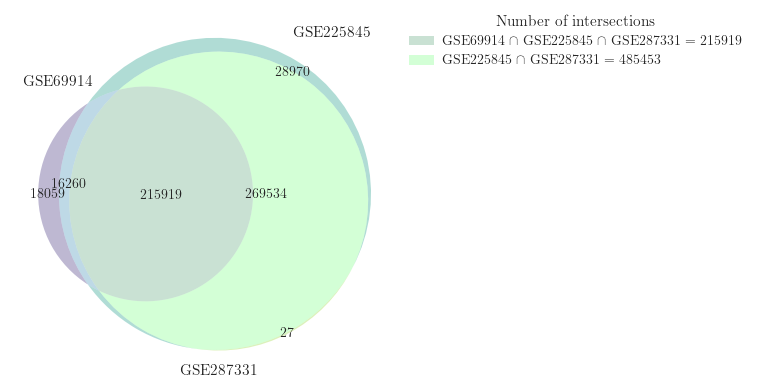

{'A_cap_B_cap_C': 215919, 'B_cap_C': 485453}

In [18]:
# POST PRE-PROCESSING CpG SETS
plot_venn3_with_clean_legend(
    cpg_69914_post,
    cpg_225845_post,
    cpg_287331_post,
    out_pdf="venn_cpg_overlap_post_preprocessing.pdf"
)


In [20]:
summary_rows = []

for name, cfg in datasets.items():
    beta  = pl.scan_parquet(cfg["beta"])
    pheno = pl.read_parquet(cfg["pheno"])

    # keep only labels of interest
    pheno = pheno.filter(pl.col(LABEL_COL).is_in(LABELS_USE))

    # sample counts
    n_samples = pheno.height
    counts = (
        pheno.group_by(LABEL_COL)
             .agg(pl.len().alias("n"))
             .to_dict(as_series=False)
    )

    # ---- CpG COUNT (PRE pre-processing) ----
    beta_cols = beta.columns
    n_cpg_pre = len(beta_cols) - len([ID_COL, LABEL_COL])

    # ---- CpG COUNT (POST pre-processing) ----
    n_cpg_post = len(cpg_post[name])

    summary_rows.append({
        "dataset": name,
        "platform": cfg["platform"],
        "samples_total": n_samples,
        "samples_normal": (
            counts["n"][counts[LABEL_COL].index(0)] if 0 in counts[LABEL_COL] else 0
        ),
        "samples_adjacent": (
            counts["n"][counts[LABEL_COL].index(1)] if 1 in counts[LABEL_COL] else 0
        ),
        "n_cpg_pre_preprocessing": n_cpg_pre,
        "n_cpg_post_preprocessing": n_cpg_post,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTDIR, "pipeline_summary.csv"), index=False)

summary_df


,dataset,platform,samples_total,samples_normal,samples_adjacent,n_cpg_pre_preprocessing,n_cpg_post_preprocessing
0,GSE69914,450K,92,50,42,485512,251483
1,GSE225845,EPIC,253,113,140,750426,530683
2,GSE287331,EPIC,242,182,60,703166,486725
